# Predicting Financial Wellbeing Among Kenyan Adults

### Objective
Build a multiclass classification model that predicts whether an individual's financial situation has:

- Improved
- Stayed the same
- Worsened

using data from the 2024 FinAccess Household Survey.

### Evaluation Metric
Weighted F1-score (chosen because the target classes are imbalanced).

In [1]:
# 1. Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from catboost import CatBoostClassifier

In [2]:
# 2. Load Data
df = pd.read_excel('finaccess2024_datasprint.xlsx')

print(f'Shape: {df.shape}')  
print()
print(df.head())

Shape: (20871, 28)

     county location_type     Sex       Age  household_size  \
0   Garissa         Urban  Female     26-35               5   
1   Garissa         Urban  Female  Above 55              11   
2     Busia         Urban  Female     26-35               2   
3    Kiambu         Urban    Male     18-25               1   
4  Murang'a         Urban  Female     18-25               1   

                                     education_level  \
0  Completed technical training after secondary s...   
1                                            "None "   
2                                "Primary completed"   
3                                   "Some secondary"   
4     Some technical training after secondary school   

                marital_status  monthly_income Savings_formal  \
0  Married/Living with partner           30000      Non-usage   
1  Married/Living with partner           10000      Non-usage   
2           Divorced/separated            3000          Usage   
3   

In [3]:
# 3. Data Types & Missing Values 
print('Column Data Types:')
print(df.dtypes)
print()
print('Missing Values per Column:')
print(df.isnull().sum())

Column Data Types:
county                   object
location_type            object
Sex                      object
Age                      object
household_size            int64
education_level          object
marital_status           object
monthly_income            int64
Savings_formal           object
Savings_informal         object
Loan_formal              object
Loan_informal            object
defaulted                object
formal_service_use       object
mobile_money_access      object
barriers_mobile_money    object
mobile_ownership_1       object
experienced_shock        object
nfhi_11                  object
nfhi_12                  object
nfhi_13                  object
accessto_13k_1month      object
not_difficult            object
financial_status         object
fl_score                 object
prodsum1                  int64
barriers_bank            object
has_disability           object
dtype: object

Missing Values per Column:
county                      0
location_type

In [4]:
# 4. Target Variable Distribution 
print('Class Distribution (counts):')
print(df['financial_status'].value_counts())
print()
print('Class Distribution (percentages):')
print(df['financial_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Class Distribution (counts):
financial_status
Worsened           10981
Stayed the same     5609
Improved            4281
Name: count, dtype: int64

Class Distribution (percentages):
financial_status
Worsened           52.6%
Stayed the same    26.9%
Improved           20.5%
Name: proportion, dtype: object


In [5]:
# 5. Summary Statistics ────────────────────────────────────────────────────────
# NOTE on monthly_income: mean > median = right-skewed distribution.
# A small group of high earners pulls the mean upward.
# The median is a better representation of the "typical" Kenyan in this dataset.
df.describe()

,household_size,monthly_income,prodsum1
count,20871.000000,20871.000000,20871.000000
mean,4.215946,9702.774280,3.936563
std,2.512658,15423.366592,3.227992
min,1.000000,100.000000,0.000000
25%,2.000000,2500.000000,1.000000
50%,4.000000,5000.000000,3.000000
75%,6.000000,10000.000000,6.000000
max,20.000000,200000.000000,22.000000


In [6]:
# 6. Remove Duplicates 
print(f'Duplicate rows found: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')  

Duplicate rows found: 5
Shape after removing duplicates: (20866, 28)


In [7]:
# 7. Handle Missing Values ─────────────────────────────────────────────────────
# barriers_bank: 27.5% missing — these respondents HAVE a bank account.
# Missing here means "no barrier applies", NOT "data not collected."
# Filling with 'No barrier' preserves this meaning when we one-hot encode later.
df['barriers_bank'] = df['barriers_bank'].fillna('No barrier')

# monthly_income: already pre-imputed with median in the curated file — no action needed.

print(f'Total missing values remaining: {df.isnull().sum().sum()}')
print()
print('barriers_bank value counts (confirming fill):')
print(df['barriers_bank'].value_counts())

Total missing values remaining: 0

barriers_bank value counts (confirming fill):
barriers_bank
Affordability              10218
No barrier                  5734
Eligibility                 1499
Relevance/Suitability       1159
Access                      1045
Awareness                    959
Trust                        171
Other                         36
Charges/Product pricing       27
Service quality               18
Name: count, dtype: int64


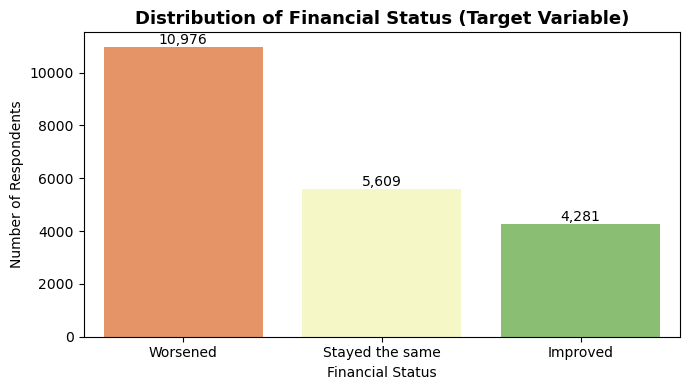

In [8]:
# 8. EDA Chart 1: Target Distribution 

order = ['Worsened', 'Stayed the same', 'Improved']

plt.figure(figsize=(7, 4))
ax = sns.countplot(x='financial_status', data=df, order=order, palette='RdYlGn')
plt.title('Distribution of Financial Status (Target Variable)', fontsize=13, fontweight='bold')
plt.xlabel('Financial Status')
plt.ylabel('Number of Respondents')

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

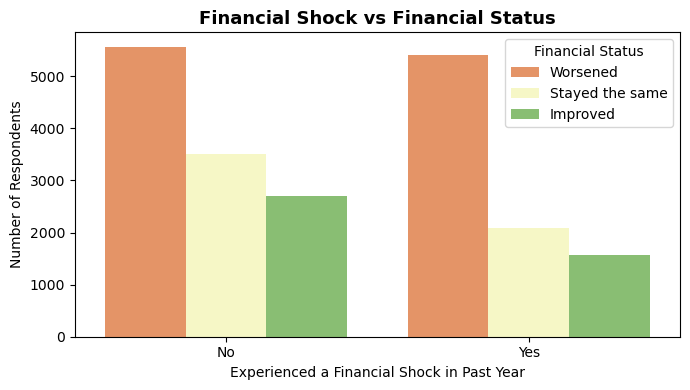

In [9]:
# 9. EDA Chart 2: Financial Shock vs Financial Status 

# INSIGHT: Experiencing a shock is one of the strongest predictors of worsening.
# Those who said 'Yes' to a shock are disproportionately in the Worsened category.
plt.figure(figsize=(7, 4))
sns.countplot(x='experienced_shock', hue='financial_status', data=df,
              hue_order=order, palette='RdYlGn')
plt.title('Financial Shock vs Financial Status', fontsize=13, fontweight='bold')
plt.xlabel('Experienced a Financial Shock in Past Year')
plt.ylabel('Number of Respondents')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

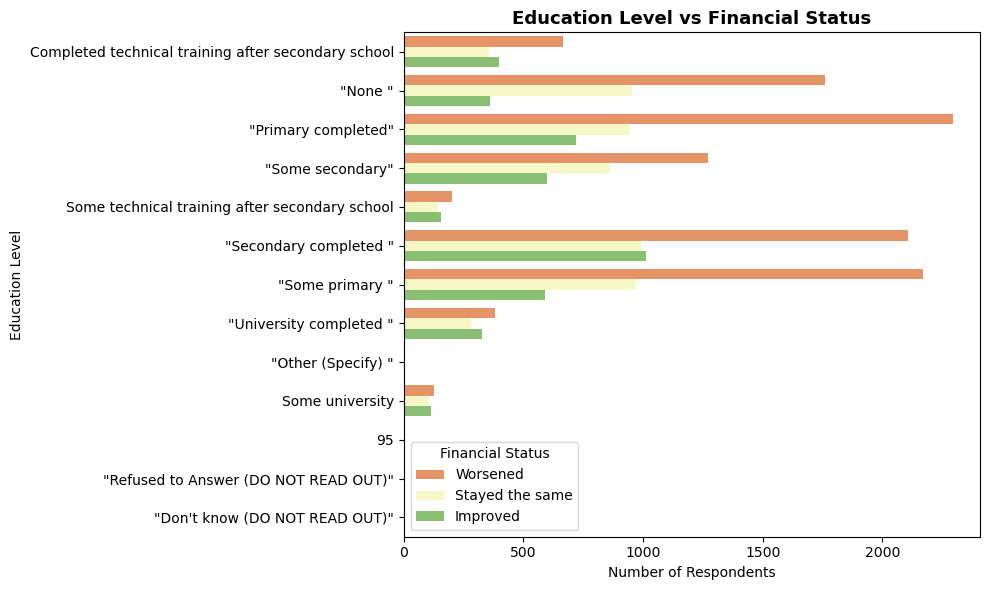

In [10]:
# 10. EDA Chart 3: Education Level vs Financial Status 

# INSIGHT: Higher education correlates with better outcomes, but no level is immune.
# This tells us behaviour and shocks matter beyond education.
plt.figure(figsize=(10, 6))
sns.countplot(y='education_level', hue='financial_status', data=df,
              hue_order=order, palette='RdYlGn')
plt.title('Education Level vs Financial Status', fontsize=13, fontweight='bold')
plt.xlabel('Number of Respondents')
plt.ylabel('Education Level')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

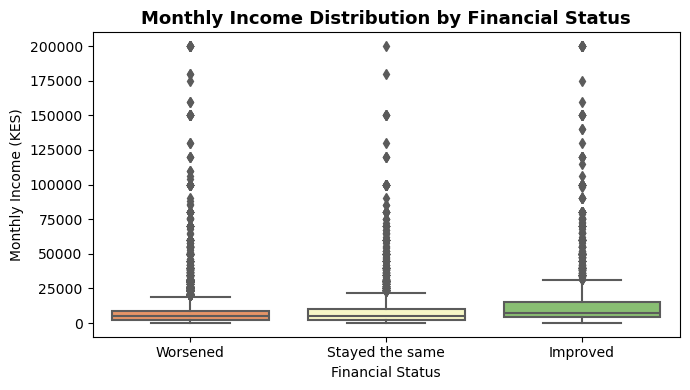

In [11]:
# 11. EDA Chart 4: Monthly Income by Financial Status 
# INSIGHT: 'Improved' respondents have higher median income, but the wide overlap
# means income is not destiny — financial behaviour and resilience matter more.
plt.figure(figsize=(7, 4))
sns.boxplot(x='financial_status', y='monthly_income', data=df,
            order=order, palette='RdYlGn')
plt.title('Monthly Income Distribution by Financial Status', fontsize=13, fontweight='bold')
plt.xlabel('Financial Status')
plt.ylabel('Monthly Income (KES)')
plt.tight_layout()
plt.show()

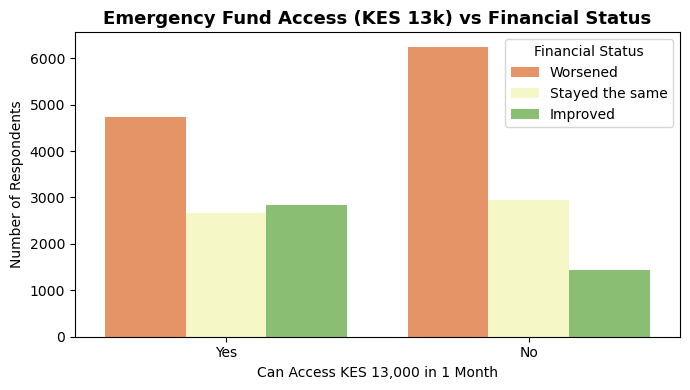

In [12]:
# 12. EDA Chart 5: Emergency Fund Access vs Financial Status 
# INSIGHT: The sharpest divide in the dataset. Those who CANNOT access emergency
# funds are concentrated almost entirely in 'Worsened'.
# This shows financial resilience (not just income) drives outcomes.
plt.figure(figsize=(7, 4))
sns.countplot(x='accessto_13k_1month', hue='financial_status', data=df,
              hue_order=order, palette='RdYlGn')
plt.title('Emergency Fund Access (KES 13k) vs Financial Status', fontsize=13, fontweight='bold')
plt.xlabel('Can Access KES 13,000 in 1 Month')
plt.ylabel('Number of Respondents')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

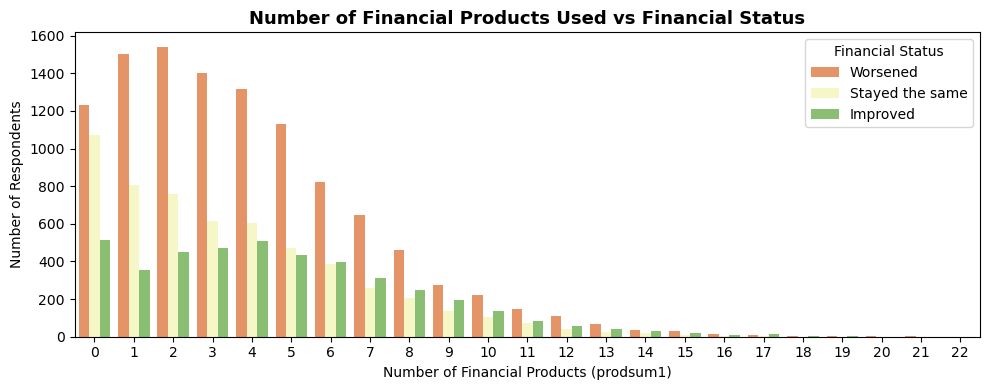

In [13]:
# 13. EDA Chart 6: Number of Financial Products vs Financial Status ─────────────
# INSIGHT: A clear gradient — more financial products used = better outcomes.
# Active inclusion (using products, not just having access) builds resilience.
plt.figure(figsize=(10, 4))
sns.countplot(x='prodsum1', hue='financial_status', data=df,
              hue_order=order, palette='RdYlGn')
plt.title('Number of Financial Products Used vs Financial Status', fontsize=13, fontweight='bold')
plt.xlabel('Number of Financial Products (prodsum1)')
plt.ylabel('Number of Respondents')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

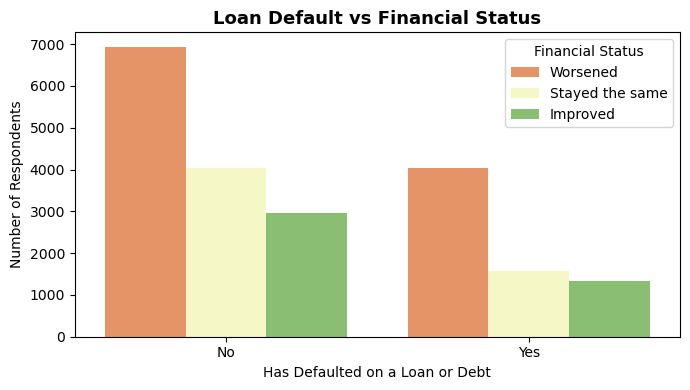

In [14]:
# 14. EDA Chart 7: Loan Default vs Financial Status ─────────────────────────────
# INSIGHT: Default is both a cause and symptom of financial deterioration.
# Those who defaulted are heavily concentrated in 'Worsened'.
plt.figure(figsize=(7, 4))
sns.countplot(x='defaulted', hue='financial_status', data=df,
              hue_order=order, palette='RdYlGn')
plt.title('Loan Default vs Financial Status', fontsize=13, fontweight='bold')
plt.xlabel('Has Defaulted on a Loan or Debt')
plt.ylabel('Number of Respondents')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

In [15]:
# 15. Feature Engineering 

# Feature 1: Financial Health Score (0-4)
# Combines the four NFHI resilience indicators into one composite score.
# Score of 4 = food secure + manages spending + no debt stress + can access emergency funds.
df['financial_health_score'] = (
    (df['nfhi_11'] == 'Yes').astype(int) +          # Food secure in past 12 months
    (df['nfhi_12'] == 'Yes').astype(int) +          # Managed non-food spending
    (df['nfhi_13'] == 'Yes').astype(int) +          # No debt stress in past 3 months
    (df['accessto_13k_1month'] == 'Yes').astype(int) # Can access emergency funds
)

# Feature 2: Fully Financially Excluded
# No formal service use AND no mobile money = the most vulnerable group.
df['fully_excluded'] = (
    (df['formal_service_use'] == 'Non-usage') &
    (df['mobile_money_access'] == 'No')
).astype(int)

# Feature 3: Has Any Savings (formal or informal)
# Any savings provides a safety net — regardless of where it's held.
df['has_any_savings'] = (
    (df['Savings_formal'] == 'Usage') |
    (df['Savings_informal'] == 'Usage')
).astype(int)

# Feature 4: Shock with No Safety Net (interaction feature) Most dangerous combination
# Neither column alone captures this risk — the interaction does.
df['shock_no_savings'] = (
    (df['experienced_shock'] == 'Yes') &
    (df['has_any_savings'] == 0)
).astype(int)


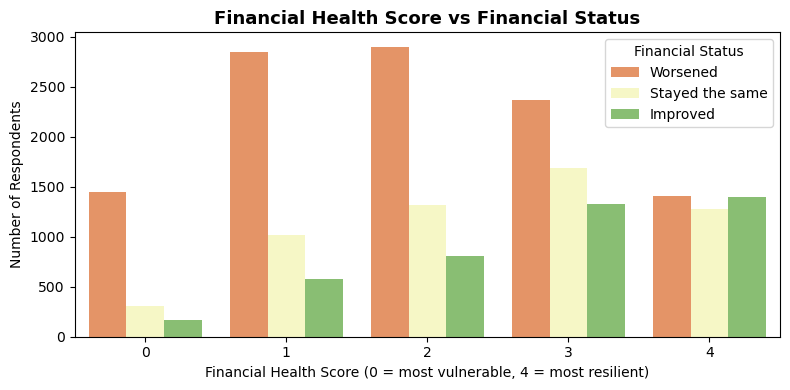

In [16]:
# 16. Validate Engineered Feature.
plt.figure(figsize=(8, 4))
sns.countplot(x='financial_health_score', hue='financial_status', data=df,
              hue_order=order, palette='RdYlGn')
plt.title('Financial Health Score vs Financial Status', fontsize=13, fontweight='bold')
plt.xlabel('Financial Health Score (0 = most vulnerable, 4 = most resilient)')
plt.ylabel('Number of Respondents')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

In [17]:
# 17. Separate Features & Target, Encode 
X = df.drop(columns=['financial_status'])
y = df['financial_status']

X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.columns = (
    X_encoded.columns
    .str.replace(r'["\'\/\s\\\[\]{}:,]', '', regex=True)
    .str.replace(r'\s+', '_', regex=True)
    .str.strip('_')
)

In [18]:
# 18. Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
# 19. Scale Numerical Features 

scaler = StandardScaler()

# Identify numeric columns to scale
num_cols = ['monthly_income', 'household_size', 'prodsum1', 'financial_health_score']
# Only scale columns that actually exist after get_dummies
num_cols = [c for c in num_cols if c in X_train.columns]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])   
X_test[num_cols] = scaler.transform(X_test[num_cols])          


Logistic Regression — Weighted F1: 0.514

                 precision    recall  f1-score   support

       Improved       0.35      0.58      0.44       856
Stayed the same       0.40      0.38      0.39      1122
       Worsened       0.70      0.54      0.61      2196

       accuracy                           0.50      4174
      macro avg       0.48      0.50      0.48      4174
   weighted avg       0.55      0.50      0.51      4174



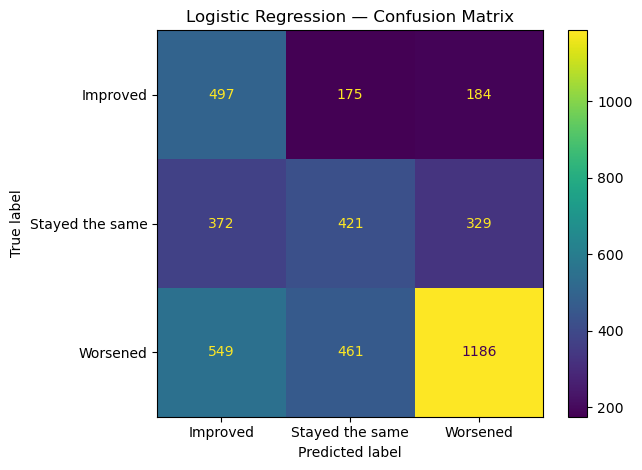

In [20]:
# 20. Model 1: Logistic Regression (Baseline) 
lr_model = LogisticRegression(
    max_iter=1000,        # enough iterations to converge
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
print(f'Logistic Regression — Weighted F1: {lr_f1:.3f}')
print()
print(classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=['Improved', 'Stayed the same', 'Worsened'])
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

Random Forest — Weighted F1: 0.546

                 precision    recall  f1-score   support

       Improved       0.40      0.47      0.43       856
Stayed the same       0.44      0.31      0.36      1122
       Worsened       0.66      0.71      0.68      2196

       accuracy                           0.55      4174
      macro avg       0.50      0.50      0.49      4174
   weighted avg       0.55      0.55      0.55      4174



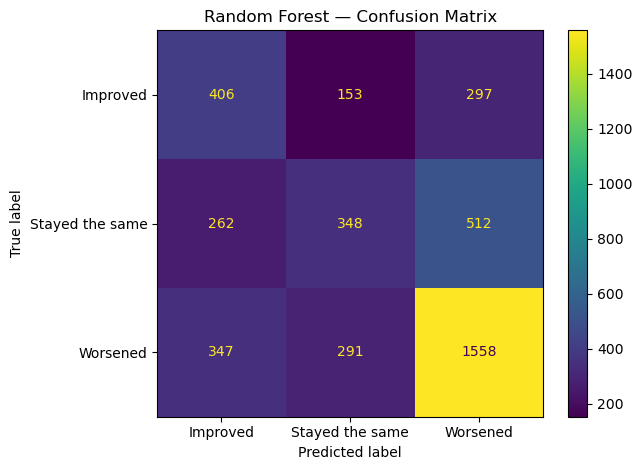

In [21]:
# 21. Model 2: Random Forest (Tuned) 

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=2,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
print(f'Random Forest — Weighted F1: {rf_f1:.3f}')
print()
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['Improved', 'Stayed the same', 'Worsened'])
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

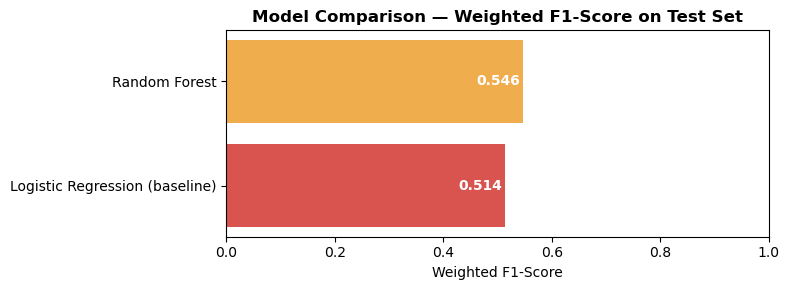

In [22]:
# 22. Model Comparison 
results = {
    'Logistic Regression (baseline)': lr_f1,
    'Random Forest':          rf_f1,
}

results_df = pd.DataFrame(results.items(), columns=['Model', 'Weighted F1'])
results_df = results_df.sort_values('Weighted F1', ascending=True)

plt.figure(figsize=(8, 3))
bars = plt.barh(results_df['Model'], results_df['Weighted F1'],
                color=['#d9534f', '#f0ad4e'])
for bar, val in zip(bars, results_df['Weighted F1']):
    plt.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='right', color='white', fontweight='bold')
plt.xlim(0, 1)
plt.xlabel('Weighted F1-Score')
plt.title('Model Comparison — Weighted F1-Score on Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

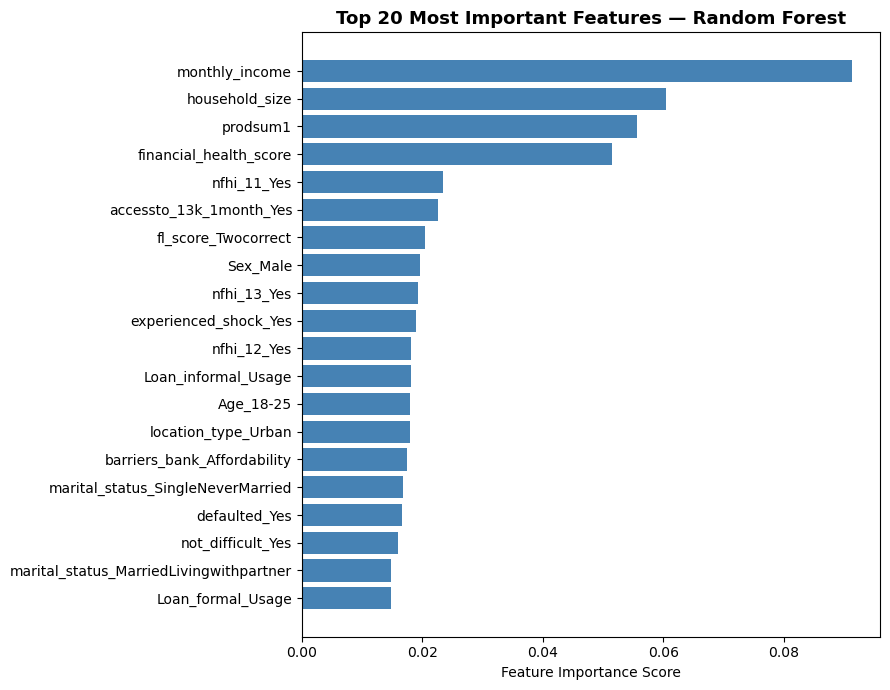

Top 10 features:
monthly_income             0.091384
household_size             0.060365
prodsum1                   0.055603
financial_health_score     0.051473
nfhi_11_Yes                0.023484
accessto_13k_1month_Yes    0.022652
fl_score_Twocorrect        0.020509
Sex_Male                   0.019544
nfhi_13_Yes                0.019332
experienced_shock_Yes      0.018984
dtype: float64


In [23]:
# ── Feature Importance — Random Forest 

feat_imp = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_features = feat_imp.nlargest(20).sort_values()

plt.figure(figsize=(9, 7))
plt.barh(top_features.index, top_features.values, color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Most Important Features — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.nlargest(10))